# ANÁLISIS DE DATOS

In [21]:
# imports:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

**RECOPILACIÓN DE DATOS**

* **Import de los datos y crear el Data Frame** 

In [22]:
df = pd.read_csv("../data/raw/internal-link.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## **ANÁLISIS DESCRITIVO**

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


**Observaciones:**

1. DIMENSIONES DEL DATASET:

> * Contiene 48895 filas y 16 columnas  
> * Columna target: 'price'

2. VAOLRES NULOS Y NO NULOS:
> * Las columnas con más valores nulos son 'last review', reviews_per_month', la diferencia es de 10.052 datos faltantes  
> * El valor de no nulos en el resto de las columnas varía ligeramente. Estas son 'name' y 'host_name'
> * El resto de columnas contienen todos los valores

3. TIPOS DE DATO:
> * Los datos que aporta el datset son diez columnas de tipo numérico (enteros y decimales) y séis columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(3), int64(7), object(6)``

## **ANÁLISIS DE COLUMNAS**

In [26]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

1. COLUMNAS Y CARACTERÍSTICAS DE LAS VARIABLES: NUMÉRICOS Y CATEGÓRICOS

NUMÉRICAS:

> Continuas:
> * ``id``, Inuméro identificador del anuncio
> * ``host_id``, identificador del anfitrión que publicó el anuncio
> * ``latitude``, posición geoográfica
> * ``longitude``, posición geográfica
> * ``price``, precio por noche del apartamento anunciado
> * ``reviews_per_month``, promedio de reseñas por mes

> Discretas:
> * ``calculated_host_listings_count``, numero de anuncios que contiene un host 
> * ``availability_365``, número de dias por año que el anuncio está disponible para alquilar
> * ``minimum_nights``, número mínim de noches para reservar el apartamento
> * ``number_of_reviews``, numero total de reseñas que ha recibido el anuncio

CATEGÓRICAS
> * ``host_name``, nombre del anfitrión
> * ``neighbourhood``, barrio
> * ``neighbourhood_group``, grupo de barrios
> * ``room_type``, tipo de habitación


# **Paso 4 - Limpieza de DATOS**

#### **Análisis y filtrado**

> 

In [27]:
df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

In [28]:
df_host_id = df.groupby('host_id').size().sort_values(ascending=False)
df_host_id

host_id
219517861    327
107434423    232
30283594     121
137358866    103
12243051      96
            ... 
13561853       1
13562603       1
13563861       1
13564519       1
13541655       1
Length: 37457, dtype: int64

In [29]:
df_host_listings_count = df.groupby('calculated_host_listings_count').size().sort_values(ascending=False)
df_host_listings_count

calculated_host_listings_count
1      32303
2       6658
3       2853
4       1440
5        845
6        570
8        416
7        399
327      327
9        234
232      232
10       210
96       192
12       180
13       130
121      121
11       110
52       104
103      103
33        99
49        98
91        91
87        87
15        75
14        70
23        69
17        68
34        68
65        65
31        62
28        56
18        54
25        50
50        50
47        47
43        43
20        40
39        39
37        37
32        32
30        30
29        29
27        27
26        26
21        21
19        19
16        16
dtype: int64

**Observaciones:**

> * Hay 4 anfitriones que tienen más de 100 anuncion publicados. El anfitrión con más anuncios tiene 327 publiaciones
> * XX

#### **Distribuciones**

*'price', 'minimum_nights' y 'host_id'*

In [30]:
df_filtered = df[(df['minimum_nights'] <=365) & (df['price'] <=1000) & (df['availability_365'] <=100)]
df_filtered

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
10,5295,Beautiful 1br on Upper West Side,7702,Lena,Manhattan,Upper West Side,40.80316,-73.96545,Entire home/apt,135,5,53,2019-06-22,0.43,1,6
11,5441,Central Manhattan/near Broadway,7989,Kate,Manhattan,Hell's Kitchen,40.76076,-73.98867,Private room,85,2,188,2019-06-23,1.50,1,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


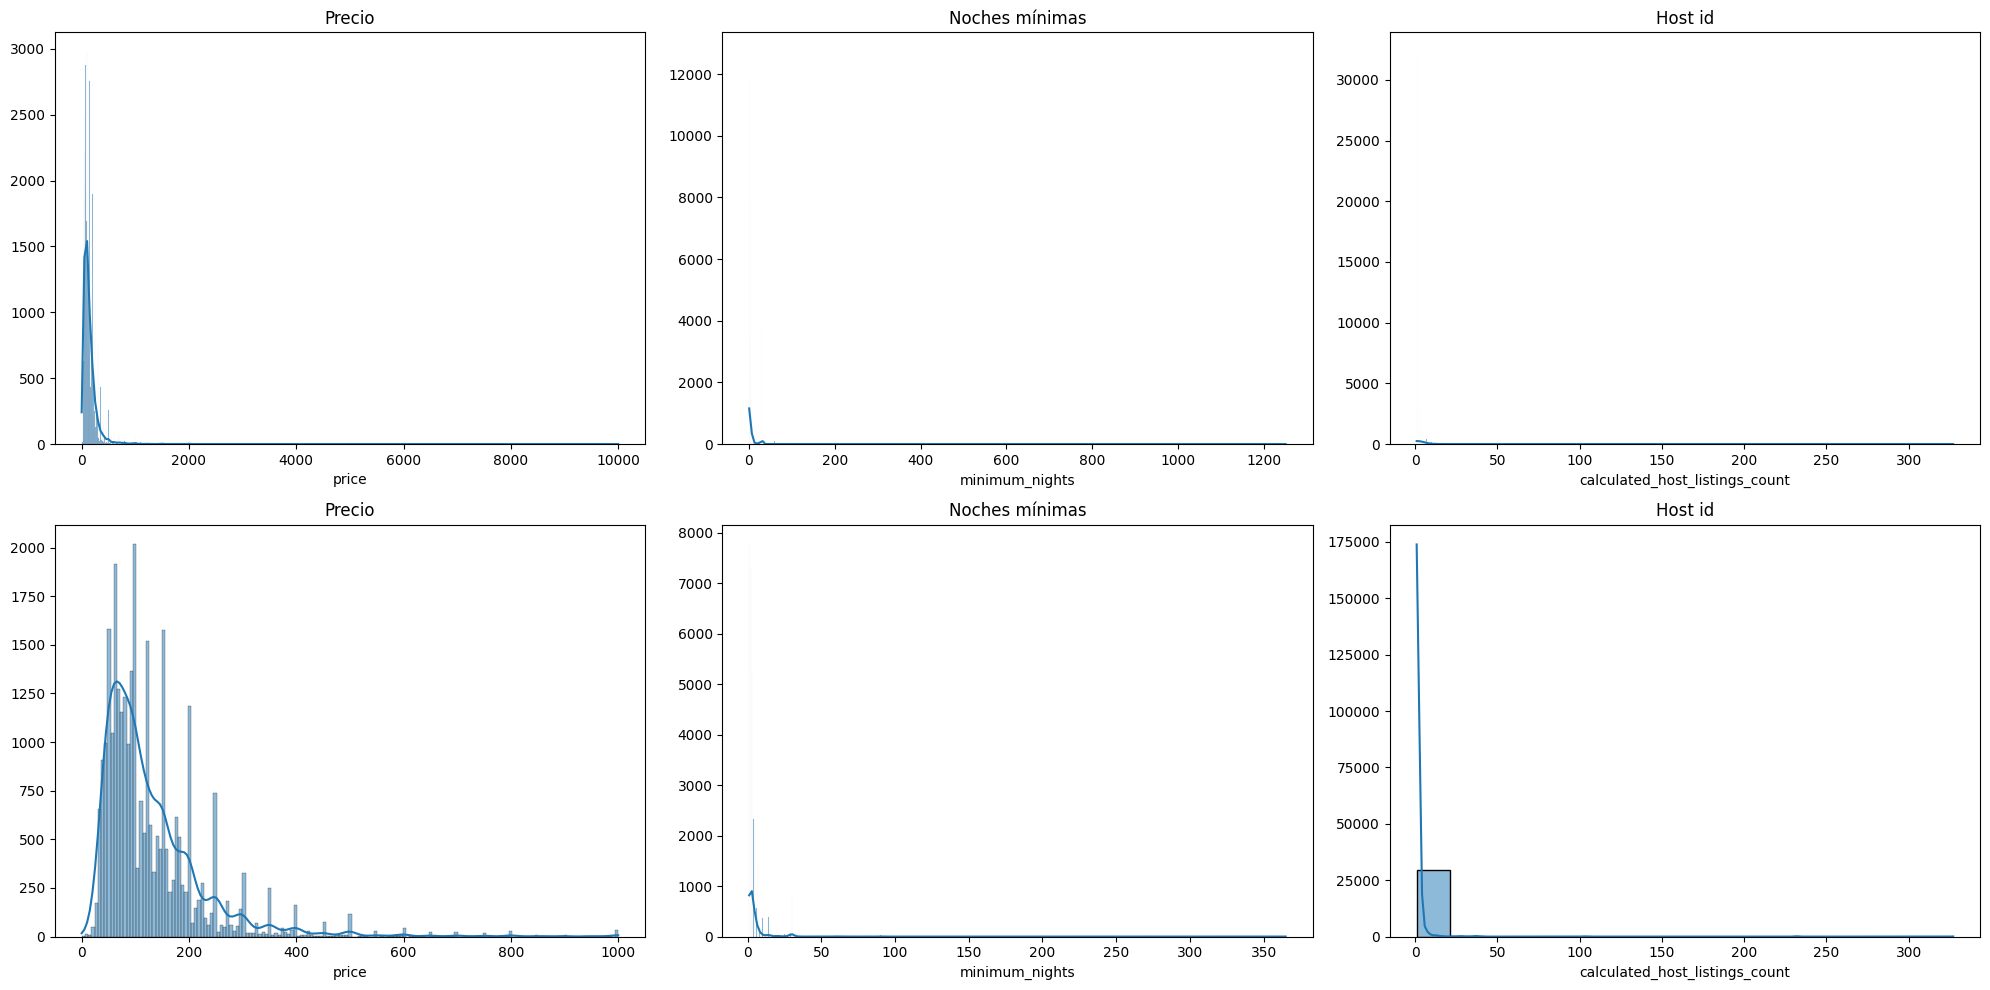

In [31]:
figs, axis = plt.subplots(2, 3, figsize=(20, 10))

sns.histplot(ax=axis[0, 0], data=df, x='price', kde=True).set(title='Precio', ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, x='minimum_nights', kde=True).set(title='Noches mínimas', ylabel=None)
sns.histplot(ax=axis[0, 2], data=df, x='calculated_host_listings_count', kde=True).set(title='Host id', ylabel=None)
sns.histplot(ax=axis[1, 0], data=df_filtered, x='price', kde=True).set(title='Precio', ylabel=None)
sns.histplot(ax=axis[1, 1], data=df_filtered, x='minimum_nights', kde=True).set(title='Noches mínimas', ylabel=None)
sns.histplot(ax=axis[1, 2], data=df_filtered, x='calculated_host_listings_count', kde=True).set(title='Host id', ylabel=None)


plt.tight_layout()

**Observaciones de los sesgos de las variables:**
> * ``price``, los valores la mayoría son valores bajos a 0 pero también se encuentran algunos valores altos indicando que algunos apartamentos tienen un precio elevado y sesgan los datos hacia la derecha
> * ``minimum_nights``, la mayoria de la data está concentrada enre 1 y 2 noches lo cuál indica que la mayor parte de los alquileres es de corta estancia y se observa otro pico alrededor las 30 noches  
En el gráfico originial hay valores mucho más altos que pueden ser posibles outliers
> * ``calculated_hist_listings_count``, existen mcuhos más propietarios que tienen 1 o 2 propiedades aunque si algunos llegan a tener más de 300 y más de 30.000 publicaciones

# **Limpieza de Datos: Eliminar información irrelevante**

**Observaciones:**

1. VARIBABLE TARGET Y PREDICTORIAS

> TARGET:
> * 'price', igual que con la columna anterior existen apartamentos con precio 0$ por noche, se eliminan esos valores

> PREDICTORAS
> * 'availability_365', hay varios apartamentos que tienen 0 días de disponibilidad quizás porque ya no ofrecen más serivicio de hospedage. Se eliminan del df para obtener un análisis de los apartamentos en activo.

2. VARIABLES DESCARTADAS
> * Hay diferencias entre el número de valores unicos que idefntfican a la persona propietaria del airbnb (``'name'``, ``'host_id'`` y ``'host_name'``). Esto deberían de tener el mismo número si la lista fuese enteramente de propietarios únicos pero algunos propietarios tienen más de un host_id ya que tienen más de un anuncio publicado como indica ``'calculated_host_listening_count'``. Se descartan esas columnas además de la columna ``'id'`` para identificar al propietario ya que no es necesario identificar el nombre del propietario o del anuncio para este análisis.
> * Las variables relacionadas con las 'reviews' también son eliminadas porque no aportan datos concretos al análisis del precio.

3. FILTRADO DE DATOS
> * ``'price'``, en precios diferentes a 0$ por noche
> * ``'minimum_nights'``, el filtro elimina los anuncios que no aportan disponibilidad de noches para reservar 
> * ``'availability_365'``, alquiler mínimo de noches menor a 365

**.drop() de las variables que se descartan:**

In [32]:
df.drop(['id','name','reviews_per_month','number_of_reviews','host_name','host_id','last_review','longitude','latitude','calculated_host_listings_count','neighbourhood'], axis=1, inplace=True)
df

,neighbourhood_group,room_type,price,minimum_nights,availability_365
0,Brooklyn,Private room,149,1,365
1,Manhattan,Entire home/apt,225,1,355
2,Manhattan,Private room,150,3,365
3,Brooklyn,Entire home/apt,89,1,194
4,Manhattan,Entire home/apt,80,10,0
...,...,...,...,...,...
48890,Brooklyn,Private room,70,2,9
48891,Brooklyn,Private room,40,4,36
48892,Manhattan,Entire home/apt,115,10,27
48893,Manhattan,Shared room,55,1,2


**Observaciones: ¿Por qué se eliminan estas variables?**
>  1. ``'id'``, ``'name'``, ``'host_id'`` y ``'host_name'``: Las variabes que identifican al host o daninformación del anuncio no son relevantespara el análisis de l variación del precio es este caso
>  2. ``'last_review'``, ``'reviews_per_month'``, ``'number_of_reviews'``: contienen varios NaNs y no aportan gran información al análisis.
> 3. ``'longitude'`` y ``'longitude'``, las descarto porque las variables ``'neighbourhood'`` y ``'neighbourhood_group'`` ya aportan la localización de los apartamentos

**Filtrado de variables:**

In [33]:
df_filtered_two= df[(df['price'] != 0) & (df['availability_365'] <= 365) & (df['minimum_nights'] <= 30)]
df_filtered_two

,neighbourhood_group,room_type,price,minimum_nights,availability_365
0,Brooklyn,Private room,149,1,365
1,Manhattan,Entire home/apt,225,1,355
2,Manhattan,Private room,150,3,365
3,Brooklyn,Entire home/apt,89,1,194
4,Manhattan,Entire home/apt,80,10,0
...,...,...,...,...,...
48890,Brooklyn,Private room,70,2,9
48891,Brooklyn,Private room,40,4,36
48892,Manhattan,Entire home/apt,115,10,27
48893,Manhattan,Shared room,55,1,2


**Observaciones:**

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   neighbourhood_group  48895 non-null  object
 1   room_type            48895 non-null  object
 2   price                48895 non-null  int64 
 3   minimum_nights       48895 non-null  int64 
 4   availability_365     48895 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.9+ MB


> * Al fltrar los apartamentos sin disponibilidad quedan 31340 48895 filas y 16 columnasfilas AÑADIR DE ANTES Y DESPUES --> ¿?¿?¿?¿?? diferencia numerica

In [35]:
print('El tiempo de estancia mínima es:', df['availability_365'].min())
print('El tiempo de estancia máxima es:', df['availability_365'].max())
print('El precio mínimo ($) por estancia:', df['price'].min())
print('El precio máximo ($) por estancia:', df['price'].max())

El tiempo de estancia mínima es: 0
El tiempo de estancia máxima es: 365
El precio mínimo ($) por estancia: 0
El precio máximo ($) por estancia: 10000


# **Análisis de Variables**


### **Variable objetivo / target**

* 'price', depende el precio por noche de la disponibilidad del apartamento?

### **Variables predictorias**

* ``'availability_365'``¿los apartamentos con mayor disponibilidad durante el año son más costosos o más económicos?
* ``'neighbourhood_group'``¿dependiendo la localización cuánto varia el precio?
* ``'room_type'`` ¿dependiendo del tipo de apartamento el precio es más variante?
* ``'minimum_nights'`` ¿los apartamentos temporales (1-2 días) son más costosos o más económicos?

### **Análisis de Variables Univariante**

*Definición: Se distinguen entre dos tipos, nuéricas y categóricas. Son datos estadístios de un conjunto de observaciones de un atributo. Análisis columna a columna, analar una variable solamente. Nos ayuda a ver la distribución de los valores y sus medidas* 

* **Análisis de variables Categóricas**

1. 'neighbourhood_group',
2. 'neighbourhood',
3. 'room_type',

*Definición: Grupos nominales de datos ?¿?¿?¿?¿?¿*

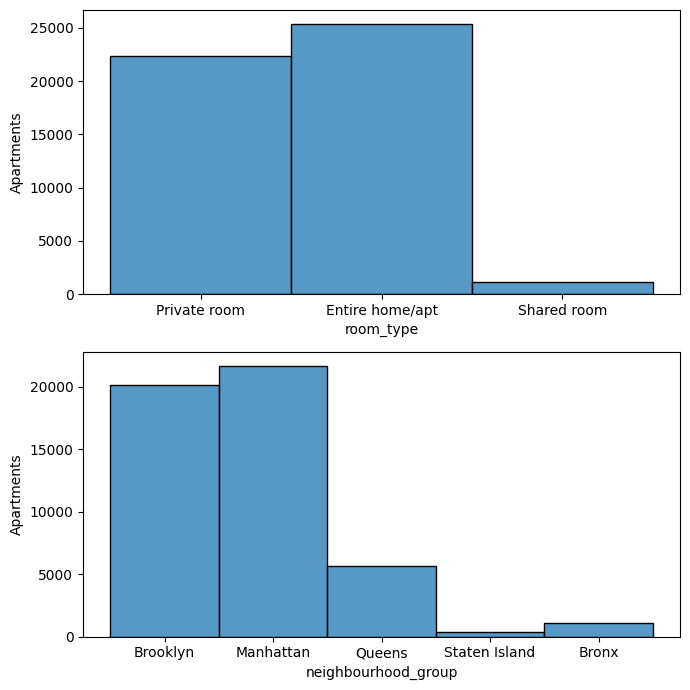

In [36]:
fig, axis = plt.subplots(2, figsize=(7, 7))
sns.histplot(ax=axis[0], data=df, x="room_type").set(ylabel='Apartments')
sns.histplot(ax=axis[1], data=df, x="neighbourhood_group").set(ylabel='Apartments')

plt.tight_layout()
plt.show()

* **Análisis de variables Numéricas** 

1. ``'price'``, precio por noche en dólares
2. ``'availability_365'``, días disponibles para reservar el apartamento por año
3. ``'minimum_nights'``, mínimo de noches para poder reservar el apartamento

In [37]:
fig, axis = plt.subplots(3, 2, figsize=(12, 6), gridspec_kw={'height_ratios': [5, 1]})

sns.histplot(ax=axis[0, 0], data=df, x="price", kde=True).set(title='Histograma, xlabel='Price', ylabel='Apartments')
sns.boxplot(ax=axis[0, 1], data=df, x="price").set(title='Boxplot', ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, x="availability_365", kde=True).set(title='Histograma', xlabel='Availability_365', ylabel='Apartments')
sns.boxplot(ax=axis[1, 1], data=df, x="availability_365").set(title='Boxplot', ylabel=None)
sns.histplot(ax=axis[2, 0], data=df, x="minimum_nights", kde=True).set(title='Histograma', xlabel='Minimum Nights', ylabel='Apartments')
sns.boxplot(ax=axis[2, 1], data=df, x="minimum_nights").set(title='Boxplot', ylabel=None)



plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 3) (4141227159.py, line 3)

**Observaciones:**


> * Ningún apartemtno tiene disponibilidad durante todo el año.
> * 

### **Análisis de Variables Multivariante**

*Definición: analizar más de una variable almismo tiempo ra ver las relaciones entre ellas*

* **Análisis de variables Numérica-Numérica**

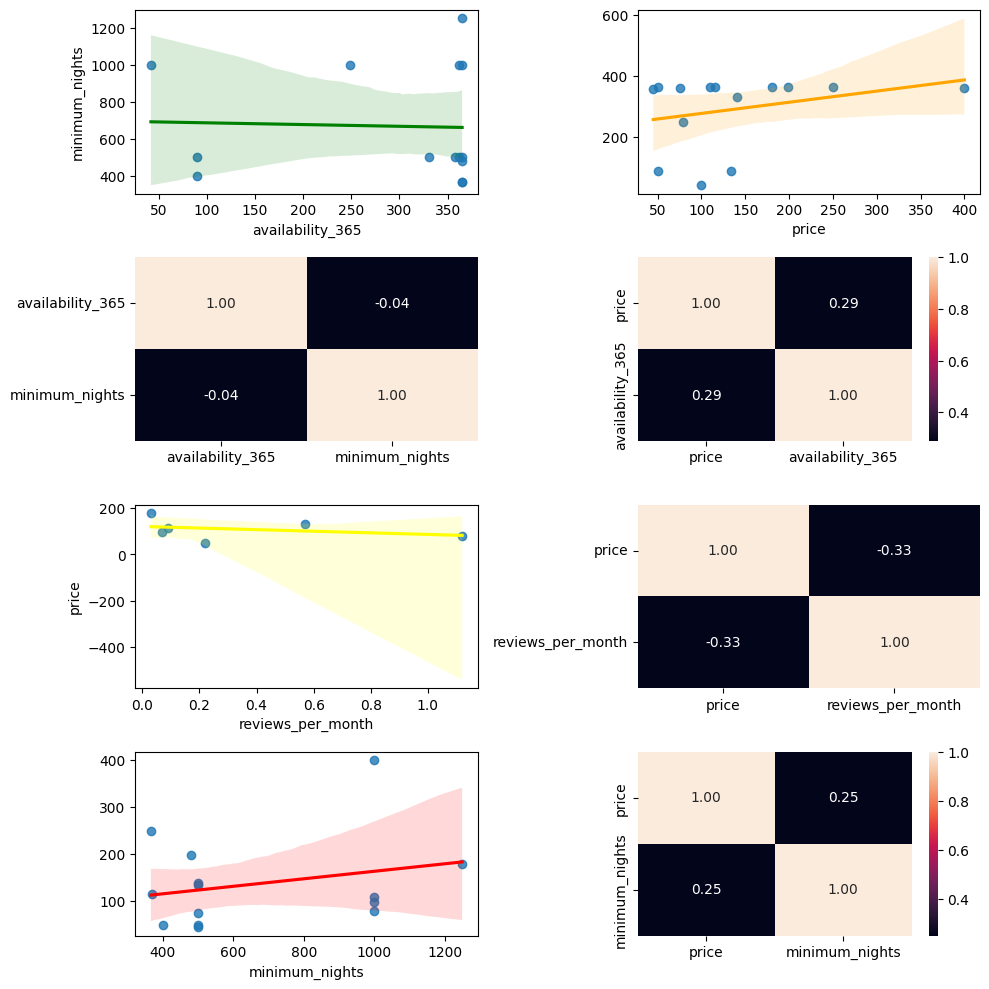

In [ ]:
# Generamos las correlaciones
corr_survived_fare = df[["availability_365", "minimum_nights"]].corr()
corr_survived_age = df[["price", "availability_365"]].corr()
corr_price_reviews = df[['price', 'reviews_per_month']].corr()
corr_price_minimum_nights = df[['price', 'minimum_nights']].corr()

# Crear un diagrama de dispersión múltiple
fig, axis = plt.subplots(4, 2, figsize=(10, 10))

sns.regplot(ax=axis[0, 0], data=df, x="availability_365", y="minimum_nights", line_kws={'color': 'green'})
sns.heatmap(ax=axis[1, 0], data=corr_survived_fare, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="price", y="availability_365", line_kws={'color': 'orange'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 1], data=corr_survived_age, annot=True, fmt=".2f")

sns.regplot(ax=axis[2, 0], data=df, x='reviews_per_month', y='price', line_kws={'color': 'yellow'})
sns.heatmap(ax=axis[2, 1], data=corr_price_reviews, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[3, 0], data=df, x='minimum_nights', y='price', line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[3, 1], data=corr_price_minimum_nights, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

**Obervaciones:**

> * Correlación negativa entre precio y reviews por mes entonces los aparmentos más caros generan menos reviews mensuales
> * Correlación positiva entre precio y noches mínima y en este caso las estancias más largas estan asociadas a precios más altos


XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

* VIOLIN PLOT ¿?

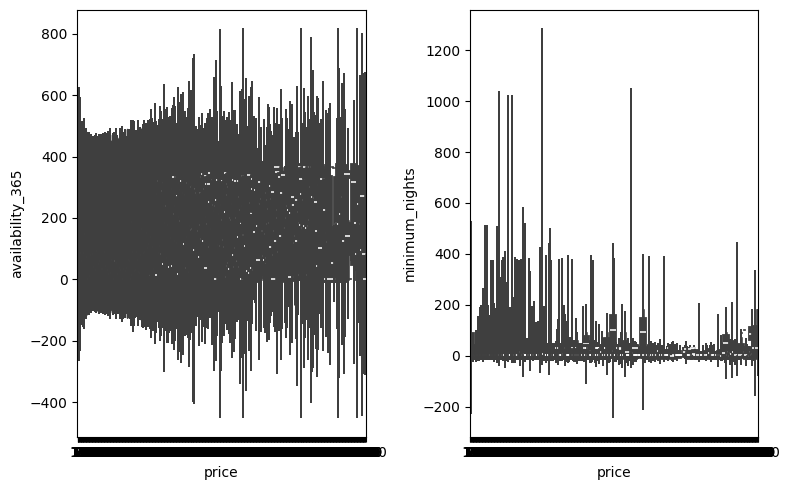

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(8, 5))

sns.violinplot(ax=axis[0], data=df, x='price', y='availability_365')
sns.violinplot(ax=axis[1], data=df, x='price', y='minimum_nights')

plt.tight_layout()
plt.show()

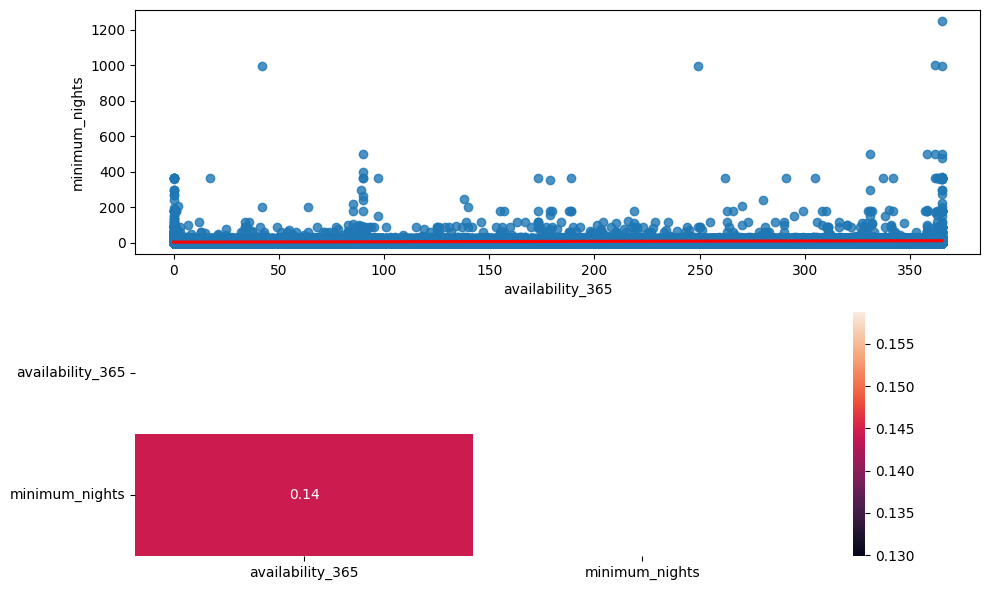

In [ ]:
# CORRELACIÓN:

corr_df = df[[ 'availability_365', 'minimum_nights']].corr()
mask_corr = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(2, 1, figsize=(10, 6))
sns.regplot(ax=axis[0], data=df, x="availability_365", y="minimum_nights", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1], data=corr_df, mask=mask_corr, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

**Observaciones:**

> * XX
> * XX

* **Análisis de variables Categórica-Categórica**

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

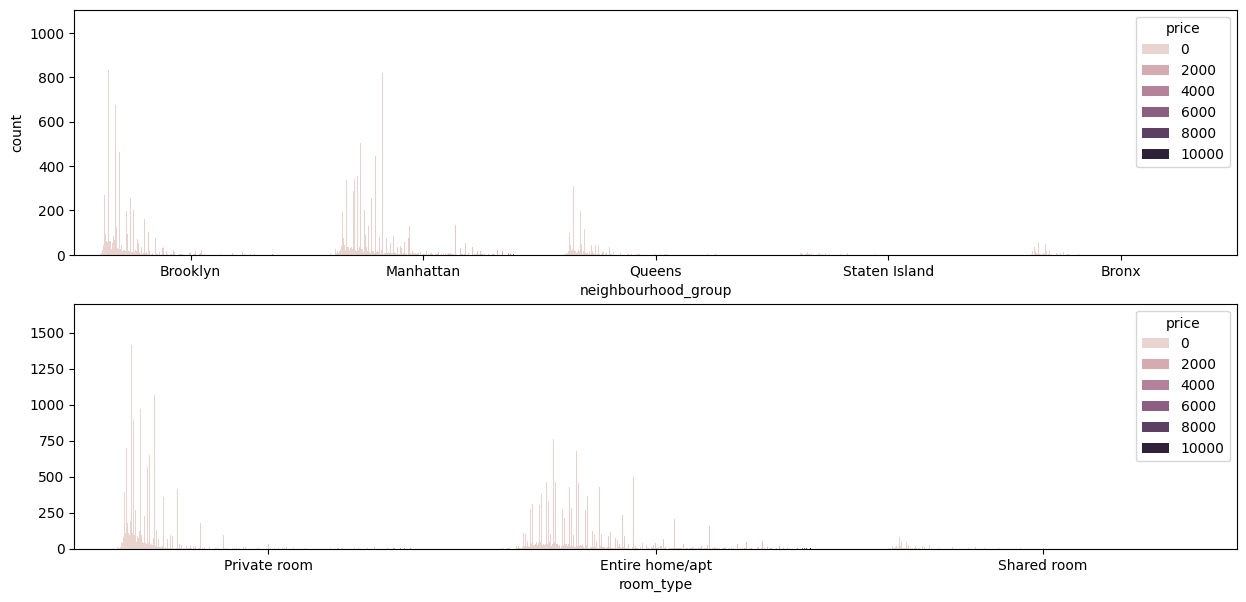

In [ ]:
fig, axis = plt.subplots(2, figsize=(15, 7))

sns.countplot(ax=axis[0], data=df, x="neighbourhood_group", hue="price")
sns.countplot(ax=axis[1], data=df, x="room_type", hue="price").set(ylabel=None)

fig.delaxes(axis[1, 2])

plt.tight_layout()
plt.show()

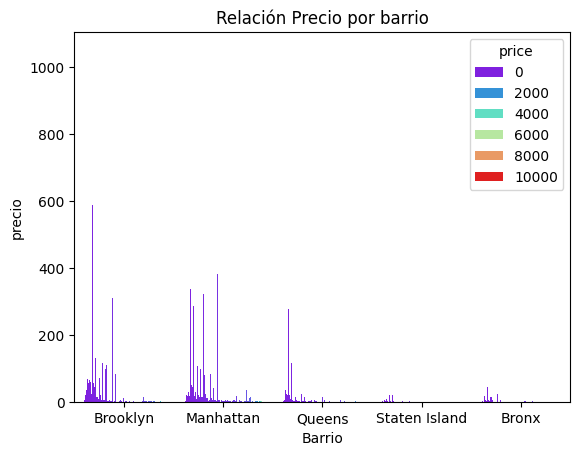

In [ ]:
sns.countplot(data=df, x='neighbourhood_group', hue='price', palette='rainbow')

plt.title('Relación Precio por barrio')
plt.xlabel('Barrio')
plt.ylabel('precio')
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'yaxis'

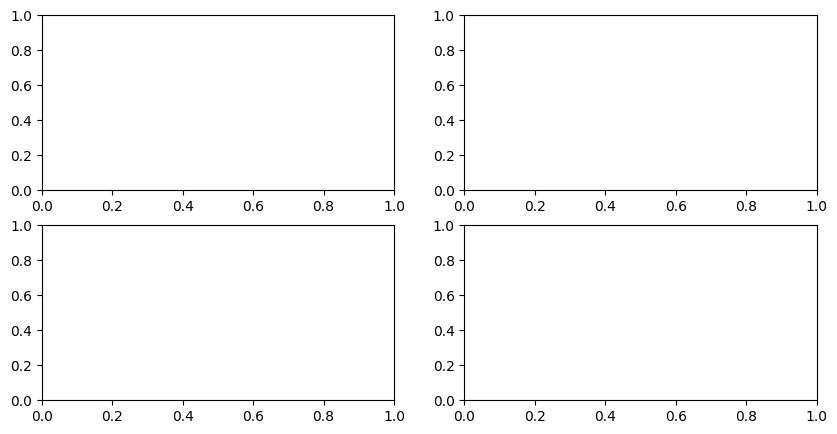

In [ ]:
fig, axis = plt.subplots(figsize=(10, 5), ncols=2)

sns.barplot(ax=axis[0], data=df, x="minimum_nights", y="price", hue="neighbourhood_group")
sns.barplot(ax=axis[1], data=df, x="availablity_365", y="price", hue="neighbourhood_group").set(ylabel=None)

plt.tight_layout()
plt.show()

In [ ]:
#para justificar describe().T
df['minimum_nights'].sort_values(ascending=False)

5767     1250
2854     1000
26341     999
13404     999
38664     999
         ... 
16504       1
16505       1
16506       1
48819       1
48821       1
Name: minimum_nights, Length: 48895, dtype: int64

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,48895.0,152.720687,240.154170,0.0,69.0,106.0,175.0,10000.0
minimum_nights,48895.0,7.029962,20.510550,1.0,1.0,3.0,5.0,1250.0
availability_365,48895.0,112.781327,131.622289,0.0,0.0,45.0,227.0,365.0


oBSERVACIONES PRICE
lat y long - cuidado al interpretar columns
price statistics - centrarse en cuartiles(analisis) - Entre 0 y 75% = 189 



**Observaciones:**



**Análisis de correlaciones:**


* **Factorizar las variables categóricas:**

In [ ]:
#TODO explain factorize method

In [ ]:
df["room_type"] = pd.factorize(df["room_type"])[0]
df["neighbourhood_group"] = pd.factorize(df["neighbourhood_group"])[0]

**Correlación de las variables categóricas:**

In [38]:
corr = df[["room_type", "neighbourhood_group", "price"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'Private room'

* **Análisis de variables Numérica-Categórica**

In [ ]:
# CORRELACIÓN

corr = df[['price', 'availability_365', 'minimum_nights','neighbourhood_group','room_type']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'Brooklyn'

**Observaciones:** 

REVISAR -------------------------------------------
> * La ubicación geográfica es un factor clave en la variación del precio
> * Estancias mínimas cortas es la variable en más correlación con el precio
> * El número de anuncios por host y el minimo de noches tienen un valor similar de correlación por lo que podemos deducir que cada host usa más o menos los mismos servicios en sus anuncios. 

## **Ingeniaria de características:**

**Análisisde ouliers**

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,48895.0,152.720687,240.154170,0.0,69.0,106.0,175.0,10000.0
minimum_nights,48895.0,7.029962,20.510550,1.0,1.0,3.0,5.0,1250.0
availability_365,48895.0,112.781327,131.622289,0.0,0.0,45.0,227.0,365.0


**Observaciones:**

IndexError: index 2 is out of bounds for axis 1 with size 2

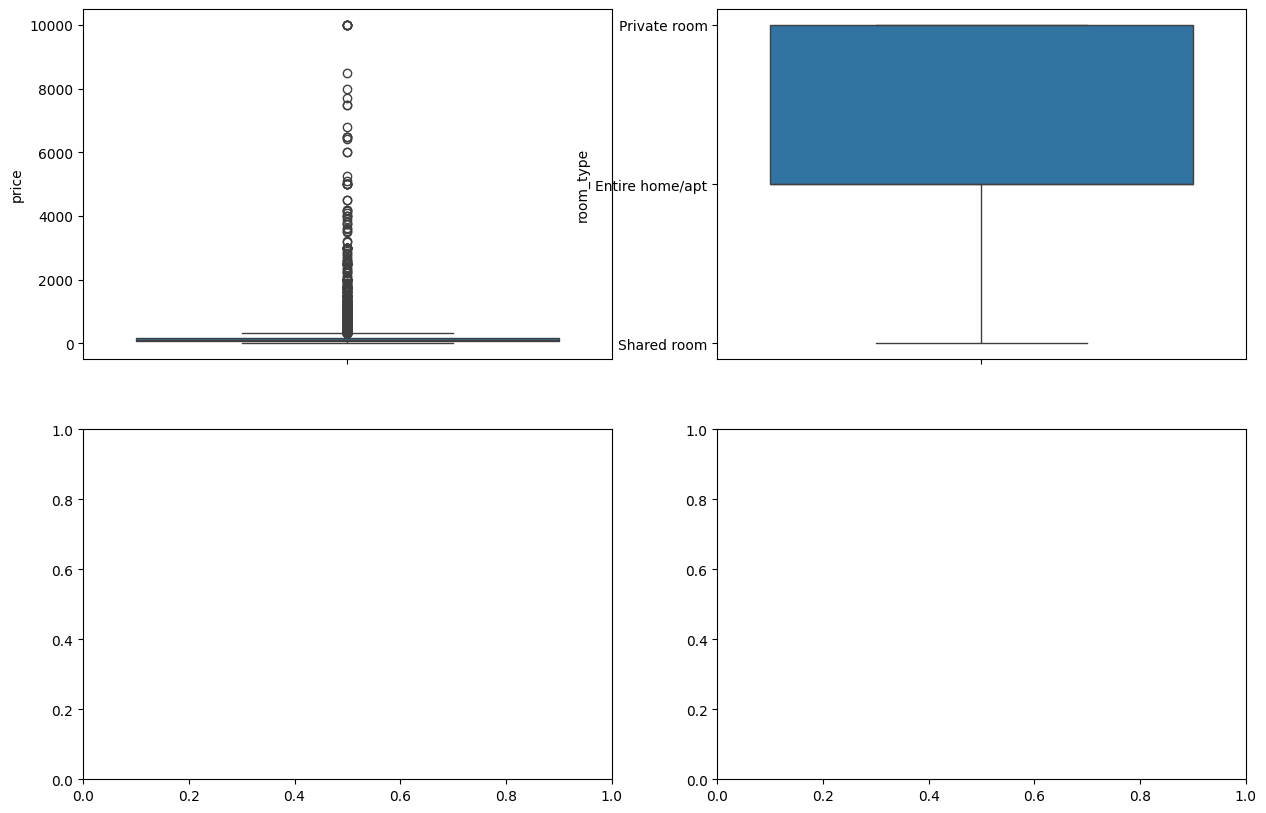

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df, y="price")
sns.boxplot(ax=axis[0, 1], data=df, y="room_type")
sns.boxplot(ax=axis[0, 2], data=df, y="neighbourhood_group")
sns.boxplot(ax=axis[1, 0], data=df, y="availability_365")
sns.boxplot(ax=axis[1, 1], data=df, y="minimum_nights")

fig.delaxes(axis[1, 1])

plt.tight_layout()
plt.show()

**Variables afectadas por los outliers**

In [42]:
price_stats = df ['price'].describe()
price_stats

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

**Observaciones:**
No sé analizar las conclusiones estadisticas

#### **Análisis de variables faltantes:**

In [53]:
df.shape()

TypeError: 'tuple' object is not callable

In [52]:
df.isnull.sum() / df.shape[0]

AttributeError: 'function' object has no attribute 'sum'

In [50]:
# Porcentaje de valores faltantes
df.isnull().sum().sort_values(ascending=False) / len(df)

neighbourhood_group    0.0
room_type              0.0
price                  0.0
minimum_nights         0.0
availability_365       0.0
dtype: float64

In [47]:
df['availability_365'].median()

np.float64(45.0)

In [48]:
df['minimum_nights'].mean()

np.float64(7.029962163820431)

In [49]:
df['availability_365'][df['neighbourhood_group'] ==3].max()

nan

**Reemplazar valores**

> * No hace falta porque no hay valores nulos en las variables seleccionadas

In [51]:
df.isnull().sum()

neighbourhood_group    0
room_type              0
price                  0
minimum_nights         0
availability_365       0
dtype: int64

## **Split**